In [1]:
from datasets import load_dataset

dataset = load_dataset("Parveshiiii/AI-vs-Real", verification_mode="no_checks")

print(dataset)
print(dataset["train"][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00005.parquet:   0%|          | 0.00/205M [00:00<?, ?B/s]

data/train-00001-of-00005.parquet:   0%|          | 0.00/309M [00:00<?, ?B/s]

data/train-00002-of-00005.parquet:   0%|          | 0.00/826M [00:00<?, ?B/s]

data/train-00003-of-00005.parquet:   0%|          | 0.00/805M [00:00<?, ?B/s]

data/train-00004-of-00005.parquet:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9999 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'binary_label'],
        num_rows: 13999
    })
})
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x426 at 0x78B603A63650>, 'binary_label': 1}


First, let's define the necessary image transformations and create a `DataLoader` to prepare the dataset for training a deep learning model. We'll use `torchvision.transforms` for image preprocessing and `torch.utils.data.DataLoader` for batching. We'll also split the dataset into training and validation sets.

In [2]:
import torch
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

# Define image transformations
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda x: x.convert('RGB')), # Ensure image is RGB
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Custom collate function to apply transformations and batch data
def custom_collate_fn(batch):
    images = [val_transform(item['image']) for item in batch]
    # Ensure labels are converted to a tensor and are float32 for BCEWithLogitsLoss
    labels = torch.tensor([item['binary_label'] for item in batch], dtype=torch.long)
    images_tensor = torch.stack(images)
    return {'image': images_tensor, 'binary_label': labels}

# Split the dataset into training and validation sets
train_size = int(0.8 * len(dataset['train']))
val_size = len(dataset['train']) - train_size

train_dataset, val_dataset = random_split(dataset['train'], [train_size, val_size])

# Create DataLoaders with the custom collate_fn
batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=custom_collate_fn)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=custom_collate_fn)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")

# Check the shapes of the first batch from the training dataloader
first_batch = next(iter(train_dataloader))
print(f"First batch from training dataloader image shape: {first_batch['image'].shape}")
print(f"First batch from training dataloader labels shape: {first_batch['binary_label'].shape}")

Number of training samples: 11199
Number of validation samples: 2800
First batch from training dataloader image shape: torch.Size([32, 3, 224, 224])
First batch from training dataloader labels shape: torch.Size([32])


Now that the data is prepared, you can define and train a PyTorch model. Here's a basic example of how you might define a simple Convolutional Neural Network (CNN) for this task.

In [3]:
import timm
import torch.nn as nn

model = timm.create_model("efficientnet_b0", pretrained=True)
model.classifier = nn.Linear(model.classifier.in_features, 2)


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [4]:
# import torch
# import torch.nn as nn
# from torch.optim import AdamW
# from tqdm import tqdm

# device = "cuda" if torch.cuda.is_available() else "cpu"
# model = model.to(device)

# criterion = nn.CrossEntropyLoss()
# optimizer = AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

# num_epochs = 10

# for epoch in range(num_epochs):
#     model.train()
#     train_loss = 0

#     for batch in tqdm(train_dataloader):
#         imgs = batch["image"].to(device)
#         labels = batch["binary_label"].to(device)

#         optimizer.zero_grad()
#         outputs = model(imgs)
#         loss = criterion(outputs, labels)

#         loss.backward()
#         optimizer.step()

#         train_loss += loss.item()

#     print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss/len(train_dataloader):.4f}")

#     # ---------------- Validation ----------------
#     model.eval()
#     val_loss = 0
#     correct = 0
#     total = 0

#     with torch.no_grad():
#         for batch in val_dataloader:
#             imgs = batch["image"].to(device)
#             labels = batch["binary_label"].to(device)

#             outputs = model(imgs)
#             loss = criterion(outputs, labels)
#             val_loss += loss.item()

#             # accuracy
#             _, predicted = torch.max(outputs, 1)
#             correct += (predicted == labels).sum().item()
#             total += labels.size(0)

#     print(f"Val Loss: {val_loss/len(val_dataloader):.4f} | Val Acc: {correct/total:.4f}")


In [6]:
# ===============================
# Imports
# ===============================
import timm
import torch
import torch.nn as nn
from torch.optim import AdamW
from tqdm import tqdm

# ===============================
# Device
# ===============================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device);

# ===============================
# Model
# ===============================
model = timm.create_model("efficientnet_b0", pretrained=True)

model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(model.classifier.in_features, 2)
)

# Freeze backbone initially
for name, param in model.named_parameters():
    if "classifier" not in name:
        param.requires_grad = False

model = model.to(device)

# ===============================
# Loss, Optimizer, Scheduler
# ===============================
criterion = nn.CrossEntropyLoss()

optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-4,
    weight_decay=5e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.3,
    patience=1
)

# ===============================
# Training Config
# ===============================
num_epochs = 10
unfreeze_epoch = 2
patience = 3
early_stop_counter = 0
best_val_loss = float("inf")

save_path = "/content/best_efficientnet_b0.pth"

# ===============================
# Training Loop
# ===============================
for epoch in range(num_epochs):

    # Unfreeze backbone
    if epoch == unfreeze_epoch:
        print("\n🔓 Unfreezing full backbone...\n")
        for param in model.parameters():
            param.requires_grad = True

        optimizer = AdamW(
            model.parameters(),
            lr=1e-4,          # lower LR after unfreeze
            weight_decay=5e-4
        )

    # ---------- TRAIN ----------
    model.train()
    train_loss = 0.0

    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        imgs = batch["image"].to(device)
        labels = batch["binary_label"].to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_dataloader)

    # ---------- VALIDATION ----------
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in val_dataloader:
            imgs = batch["image"].to(device)
            labels = batch["binary_label"].to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_dataloader)
    val_acc = correct / total

    print("\n----------------------------")
    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print(f"Val Acc:    {val_acc:.4f}")
    print("----------------------------")

    # Scheduler step
    scheduler.step(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), save_path)
        print("✅ Saved BEST model")
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        print(f"⚠ No improvement ({early_stop_counter}/{patience})")

    # Early stopping
    if early_stop_counter >= patience:
        print("⛔ Early stopping triggered")
        break

print("\n🎉 Training complete")
print("Best model saved at:", save_path)

Using device: cuda


Epoch 1/10: 100%|██████████| 350/350 [02:19<00:00,  2.51it/s]



----------------------------
Epoch 1
Train Loss: 0.2832
Val Loss:   0.1870
Val Acc:    0.9407
----------------------------
✅ Saved BEST model


Epoch 2/10: 100%|██████████| 350/350 [02:13<00:00,  2.61it/s]



----------------------------
Epoch 2
Train Loss: 0.1575
Val Loss:   0.1483
Val Acc:    0.9464
----------------------------
✅ Saved BEST model

🔓 Unfreezing full backbone...



...


----------------------------
Epoch 8
Train Loss: 0.0021
Val Loss:   0.0110
Val Acc:    0.9946
----------------------------
✅ Saved BEST model


Epoch 9/10: 100%|██████████| 350/350 [02:46<00:00,  2.10it/s]



----------------------------
Epoch 9
Train Loss: 0.0035
Val Loss:   0.0129
Val Acc:    0.9950
----------------------------
⚠ No improvement (1/3)


Epoch 10/10: 100%|██████████| 350/350 [02:47<00:00,  2.09it/s]



----------------------------
Epoch 10
Train Loss: 0.0015
Val Loss:   0.0097
Val Acc:    0.9961
----------------------------
✅ Saved BEST model

🎉 Training complete
Best model saved at: /content/best_efficientnet_b0.pth



📊 Classification Report (threshold = 0.5)
              precision    recall  f1-score   support

           0     0.9941    0.9897    0.9919       677
           1     0.9967    0.9981    0.9974      2123

    accuracy                         0.9961      2800
   macro avg     0.9954    0.9939    0.9946      2800
weighted avg     0.9961    0.9961    0.9961      2800

📈 ROC-AUC: 0.9999304236988015

🧩 Confusion Matrix
[[ 670    7]
 [   4 2119]]


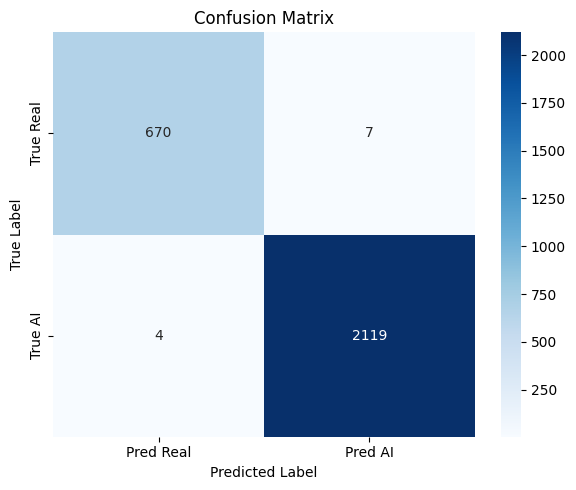

In [7]:
# ===============================
# Evaluation + Confusion Matrix
# ===============================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix
)

# Load BEST model
model.load_state_dict(
    torch.load(save_path, map_location=device)
)
model.eval()

all_labels = []
all_probs = []

# ---------- Inference ----------
with torch.no_grad():
    for batch in val_dataloader:
        imgs = batch["image"].to(device)
        labels = batch["binary_label"].to(device)

        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)[:, 1]  # prob of class = 1 (AI)

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# ---------- Metrics ----------
threshold = 0.5
all_preds = (all_probs > threshold).astype(int)

print("\n📊 Classification Report (threshold = 0.5)")
print(classification_report(all_labels, all_preds, digits=4))

roc_auc = roc_auc_score(all_labels, all_probs)
print("📈 ROC-AUC:", roc_auc)

# ---------- Confusion Matrix ----------
cm = confusion_matrix(all_labels, all_preds)

print("\n🧩 Confusion Matrix")
print(cm)

# ---------- Plot Confusion Matrix ----------
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Real", "Pred AI"],
    yticklabels=["True Real", "True AI"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
